In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# 1. Data Loading

In [3]:
# Loading data and previewing the dataset
df = pd.read_csv("../data/ab_test_data.csv")
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [ ]:
# Checking dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


# 2. Data Preparation 

In [31]:
# Converting timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Keeping only valid A/B test groups
df = df[df["test_group"].isin(["a", "b"])].copy()

# Making sure conversion is stored as an integer binary variable
df["conversion"] = df["conversion"].astype(int)

# 3. Test Overview 

In [6]:
# Test period
start_date = df["timestamp"].min()
end_date = df["timestamp"].max()
duration_days = (end_date - start_date).days

print("Test start date:", start_date.date())
print("Test end date:", end_date.date())
print("Test duration in days:", duration_days)

Test start date: 2023-07-03
Test end date: 2023-07-25
Test duration in days: 21


# 4. Metrics Calculation

In [33]:
# Splitting data by test group
group_a = df[df["test_group"] == "a"]
group_b = df[df["test_group"] == "b"]

# Number of users
n_a = group_a["conversion"].count()
n_b = group_b["conversion"].count()

# Number of conversions
conv_a = group_a["conversion"].sum()
conv_b = group_b["conversion"].sum()

# Conversion rates
cr_a = conv_a / n_a
cr_b = conv_b / n_b

# Uplift
absolute_uplift = cr_b - cr_a
relative_uplift = absolute_uplift / cr_a 

print("Group A (control)")
print("Users:", n_a)
print("Conversions:", conv_a)
print(f"Conversion rate: {cr_a:.2%}")

print("\nGroup B (variant)")
print("Users:", n_b)
print("Conversions:", conv_b)
print(f"Conversion rate: {cr_b:.2%}")

print("\nUplift")
print(f"Absolute uplift: {absolute_uplift:.2%}")
print(f"Relative uplift: {relative_uplift:.2%}")

Group A (control)
Users: 10013
Conversions: 611
Conversion rate: 6.10%

Group B (variant)
Users: 9985
Conversions: 889
Conversion rate: 8.90%

Uplift
Absolute uplift: 2.80%
Relative uplift: 45.91%


# 5. Statistical Test 

In [12]:
# Two-proportion z-test

z_stat, p_value = proportions_ztest(
    count=[conv_a, conv_b],
    nobs=[n_a, n_b]
)

alpha = 0.05

print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.10f}")

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("The difference between groups is statistically significant.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("The difference between groups is not statistically significant.")

z-statistic: -7.5197
p-value: 0.0000000000

Result: Reject the null hypothesis.
The difference between groups is statistically significant.


In [15]:
# Conversion rate over time

daily_conversion = (
    df.groupby([df["timestamp"].dt.date, "test_group"])
    .agg(users=("conversion", "count"),
        conversions=("conversion", "sum")).reset_index()
)

daily_conversion["conversion_rate"] = (
    daily_conversion["conversions"] / daily_conversion["users"]
)

daily_conversion.head()

,timestamp,test_group,users,conversions,conversion_rate
0,2023-07-03,a,412,21,0.050971
1,2023-07-03,b,445,39,0.087640
2,2023-07-04,a,446,29,0.065022
3,2023-07-04,b,452,37,0.081858
4,2023-07-05,a,436,28,0.064220


# 6. Visualisations

In [38]:
import matplotlib.ticker as mtick

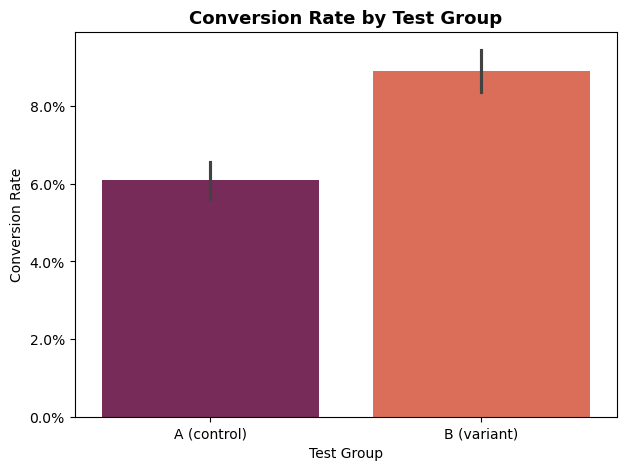

In [43]:
# Visualization: conversion rate by test group 

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="test_group",
    y="conversion",
    errorbar=("ci", 95),
    hue="test_group",
    palette = "rocket"
)

plt.title("Conversion Rate by Test Group", fontsize = 13, fontweight = "bold")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate")
plt.xticks(ticks=[0, 1], labels=["A (control)", "B (variant)"])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

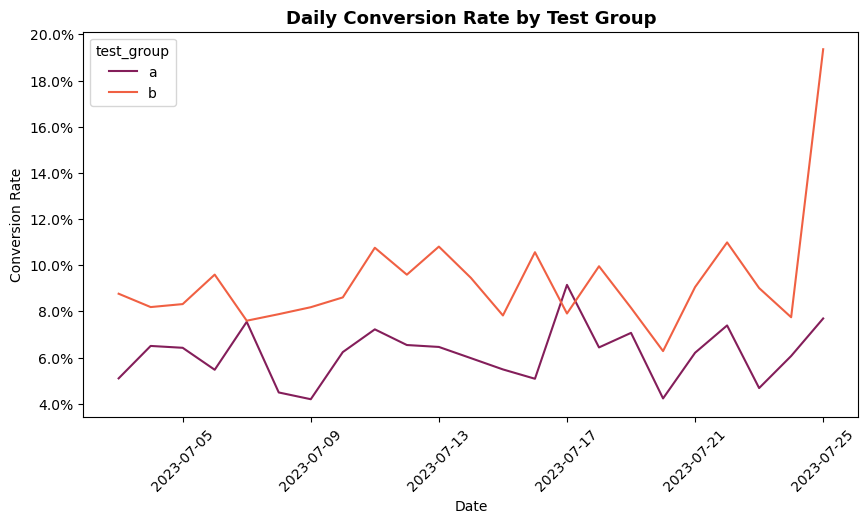

In [42]:
# Visualization: conversion rate over time

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=daily_conversion,
    x="timestamp",
    y="conversion_rate",
    hue="test_group",
    palette = "rocket"
)
plt.title("Daily Conversion Rate by Test Group",fontsize = 13, fontweight = "bold")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)

plt.show()

# Conclusion 
Group B shows higher conversion and the difference is statistically significant.